# 01 — Генерация данных

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import ensure_dir, set_seed, save_dataframe, save_json, load_dataframe
from src.systems import cross_coupled_uncontrolled
from src.simulation import simulate_batch, uncertain_dynamics
from src.plots import set_plot_style, save_figure, plot_phase_trajectories, plot_residual_histogram, plot_lyapunov_contours
from src.basis import get_basis
from src.identification import fit_identified_model, predict_vector_field, rmse
from src.uncertainty import compute_residuals, residual_norms, estimate_epsilon, compute_bounding_box, bounded_disturbance
from src.lyapunov import numerical_jacobian, solve_lyapunov, evaluate_lyapunov_grid
from src.control import candidate_gains, closed_loop_jacobian

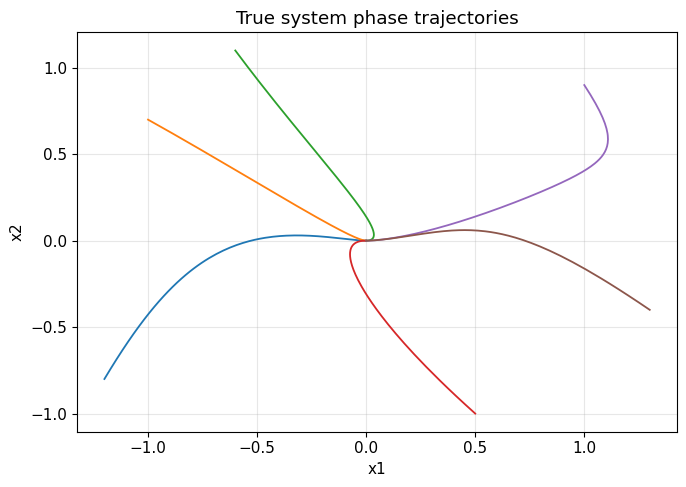

In [6]:
set_seed(42)
set_plot_style()
ensure_dir('data/processed')
ensure_dir('results/figures')

t_eval = np.linspace(0.0, 10.0, 400)
initials = np.array([[-1.2, -0.8], [-1.0, 0.7], [-0.6, 1.1], [0.5, -1.0], [1.0, 0.9], [1.3, -0.4]], dtype=float)
traj = simulate_batch(cross_coupled_uncontrolled, initials, (0.0, 10.0), t_eval)

x = np.vstack([states for _, states in traj])
xdot = np.vstack([np.array([cross_coupled_uncontrolled(float(t), s) for t, s in zip(ts, states)]) for ts, states in traj])
df = pd.DataFrame(np.hstack([x, xdot]), columns=['x1','x2','xdot1','xdot2'])
save_dataframe(df, 'data/processed/cross_coupled_dataset.csv')

plt.figure(); plot_phase_trajectories(traj, 'True system phase trajectories'); save_figure('results/figures/phase_true.png'); plt.show()
